In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load simulated data
df = pd.read_csv("../../data/raw/simulated_wind_farm_scada.csv")

# Preview the data
df.head()

,timestamp,turbine_id,true_wind_speed_ms,nacelle_wind_speed_ms,wind_direction_deg,temperature_c,pressure_hpa,air_density_kgm3,turbulence_intensity,power_kw,rotor_speed_rpm,blade_pitch_deg,operating_state,curtailment_flag,downtime_flag,wake_sector_flag,latent_sensor_bias_ms,latent_performance_factor,true_underperformance_flag
0,2025-01-01 00:00:00,T01,8.964,9.049,233.7,11.04,848.94,1.0407,0.1347,665.82,13.07,0.76,normal,0,0,1,-0.1508,1.0,0
1,2025-01-01 00:10:00,T01,8.487,8.731,231.7,9.35,846.21,1.0435,0.1559,462.62,11.45,1.05,normal,0,0,1,-0.1508,1.0,0
2,2025-01-01 00:20:00,T01,8.689,8.923,229.4,8.70,838.43,1.0363,0.1530,522.24,12.10,1.59,normal,0,0,1,-0.1508,1.0,0
3,2025-01-01 00:30:00,T01,9.180,8.770,231.3,5.64,843.56,1.0541,0.1522,777.16,13.07,2.00,normal,0,0,1,-0.1508,1.0,0
4,2025-01-01 00:40:00,T01,9.043,8.433,226.4,4.33,839.87,1.0544,0.1507,632.62,11.51,1.36,normal,0,0,1,-0.1508,1.0,0


In [3]:
import os

print(os.getcwd())

C:\Users\alex-\OneDrive\Documents\GitHub\CU-Capstone-Project\notebooks\alex_notebooks


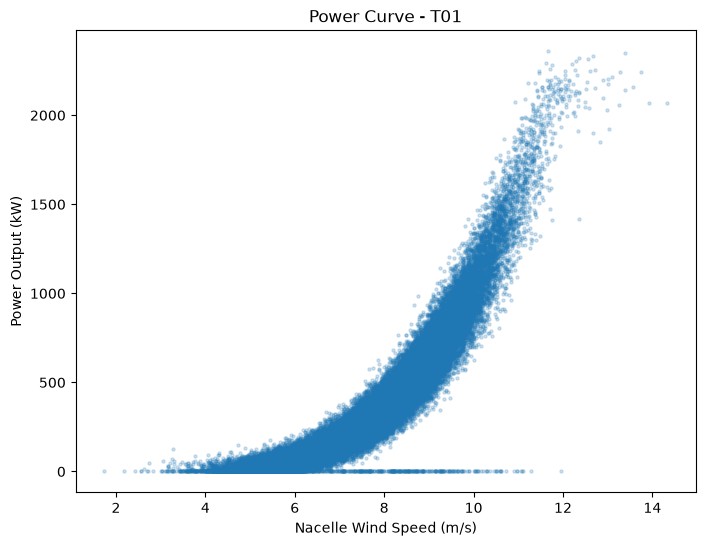

In [5]:
import matplotlib.pyplot as plt

t01 = df[df["turbine_id"] == "T01"]

plt.figure(figsize=(8, 6))

plt.scatter(
    t01["nacelle_wind_speed_ms"],
    t01["power_kw"],
    s=5,
    alpha=0.2
)

plt.xlabel("Nacelle Wind Speed (m/s)")
plt.ylabel("Power Output (kW)")
plt.title("Power Curve - T01")

plt.show()

In [6]:
normal_data = df[
    (df["downtime_flag"] == 0) &
    (df["curtailment_flag"] == 0)
]

t01 = normal_data[
    normal_data["turbine_id"] == "T01"
]

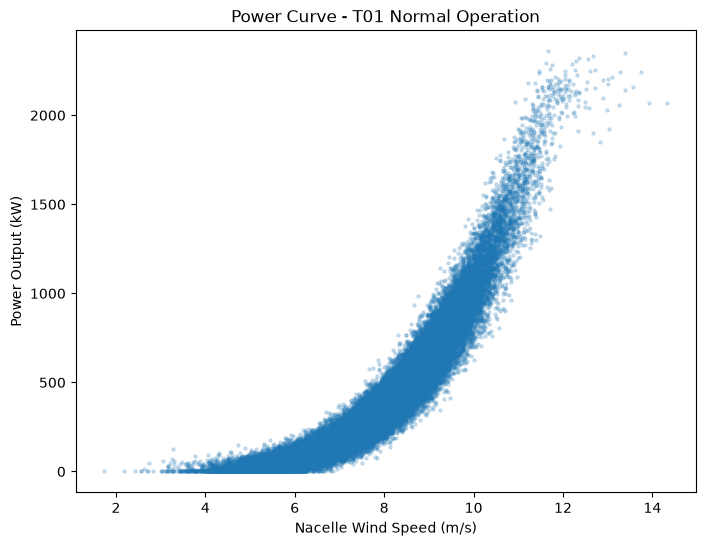

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    t01["nacelle_wind_speed_ms"],
    t01["power_kw"],
    s=5,
    alpha=0.2
)

plt.xlabel("Nacelle Wind Speed (m/s)")
plt.ylabel("Power Output (kW)")
plt.title("Power Curve - T01 Normal Operation")

plt.show()

In [8]:
import numpy as np

t01 = t01.copy()

t01["wind_speed_bin"] = (
    np.floor(t01["nacelle_wind_speed_ms"] / 0.5) * 0.5
)

power_curve = (
    t01.groupby("wind_speed_bin")["power_kw"]
    .mean()
    .reset_index()
)

power_curve.head()

,wind_speed_bin,power_kw
0,1.5,0.000000
1,2.0,0.000000
2,2.5,9.362857
3,3.0,16.711000
4,3.5,12.337921


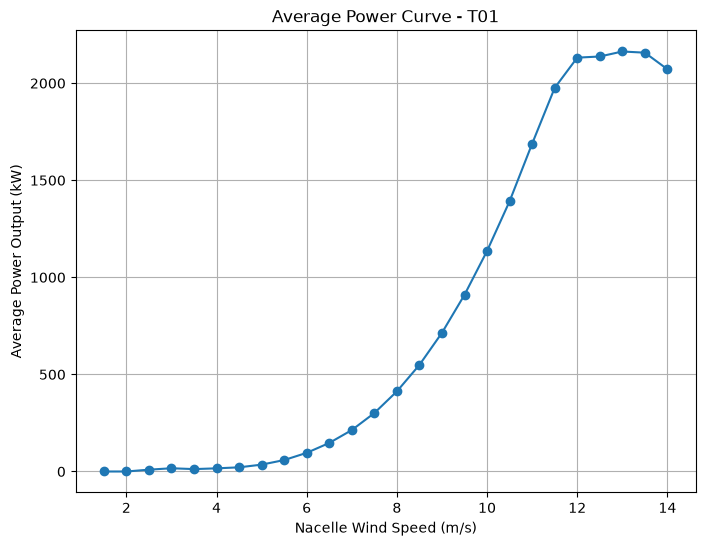

In [9]:
plt.figure(figsize=(8, 6))

plt.plot(
    power_curve["wind_speed_bin"],
    power_curve["power_kw"],
    marker="o"
)

plt.xlabel("Nacelle Wind Speed (m/s)")
plt.ylabel("Average Power Output (kW)")
plt.title("Average Power Curve - T01")

plt.grid(True)

plt.show()

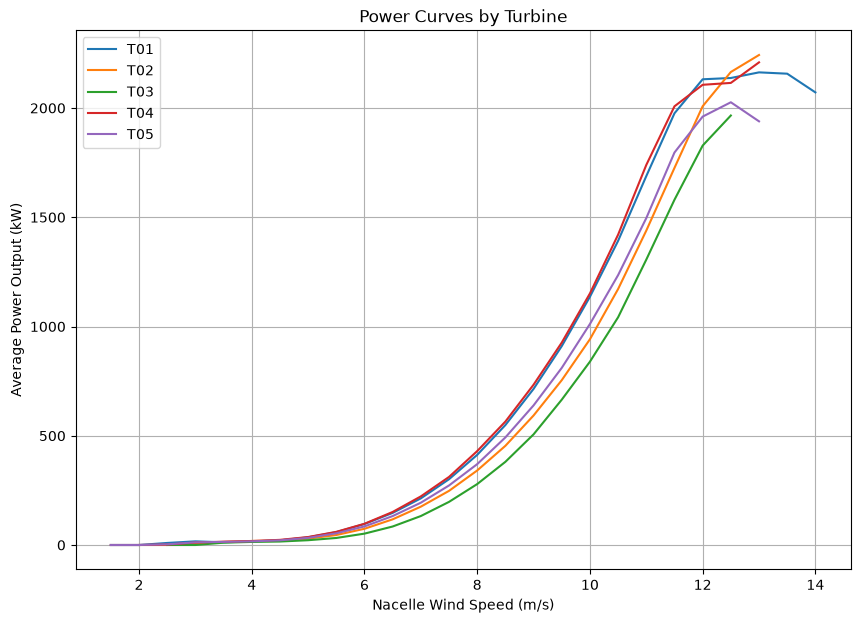

In [10]:
plt.figure(figsize=(10, 7))

for turbine in ["T01", "T02", "T03", "T04", "T05"]:

    temp = normal_data[
        normal_data["turbine_id"] == turbine
    ].copy()

    temp["wind_speed_bin"] = (
        np.floor(temp["nacelle_wind_speed_ms"] / 0.5) * 0.5
    )

    curve = (
        temp.groupby("wind_speed_bin")["power_kw"]
        .mean()
        .reset_index()
    )

    plt.plot(
        curve["wind_speed_bin"],
        curve["power_kw"],
        label=turbine
    )

plt.xlabel("Nacelle Wind Speed (m/s)")
plt.ylabel("Average Power Output (kW)")
plt.title("Power Curves by Turbine")

plt.legend()
plt.grid(True)

plt.show()